In [63]:
import pandas as pd
pd.set_option('mode.chained_assignment', None)
import numpy as np

data = pd.read_csv('kyochon.csv', index_col = 0, encoding = 'CP949', engine = 'python')
data.head()

,store,sido,gungu,store_address
0,가락2호,서울,송파구,서울 송파구 가락동 75-7
1,가산디지털,서울,금천구,서울 금천구 가산동 371-6 가산비지니스센터 2층
2,가양,서울,강서구,서울 강서구 등촌동 75-1
3,강남역,서울,서초구,서울 서초구 서초동 1309-6
4,강서구청,서울,강서구,서울 강서구 화곡동 986-16


In [64]:
addr = pd.DataFrame(data['store_address'].apply(lambda v: v.split()[:2]).tolist(),
                    columns = ('시도', '군구'))
addr.head()

,시도,군구
0,서울,송파구
1,서울,금천구
2,서울,강서구
3,서울,서초구
4,서울,강서구


In [65]:
addr['시도'].unique()

array(['서울', '서울특별시', '부산', '대구', '대구시', '인천', '광주', '대전', '울산', '세종',
       '세종특별자치시', '세종시', '경기', '경기도', '강원', '충북', '충남', '전북', '전남', '경북',
       '경남', '제주'], dtype=object)

In [66]:
addr_aliases = {'경기':'경기도', '경남':'경상남도', '경북':'경상북도', '충북':'충청북도',
                '충남':'충청남도', '서울':'서울특별시', '부산':'부산광역시', '대구':'대구광역시',
                '대구시':'대구광역시', '인천':'인천광역시', '광주':'광주광역시', '대전':'대전광역시',
                '제주':'제주특별자치도', '전북':'전라북도', '전남':'전라남도', '강원':'강원도'
                ,'울산':'울산광역시', '세종':'세종특별자치시', '세종시':'세종특별자치시'}

In [67]:
addr['시도'] = addr['시도'].apply(lambda v: addr_aliases.get(v, v))

In [68]:
addr['시도'].unique()

array(['서울특별시', '부산광역시', '대구광역시', '인천광역시', '광주광역시', '대전광역시', '울산광역시',
       '세종특별자치시', '경기도', '강원도', '충청북도', '충청남도', '전라북도', '전라남도', '경상북도',
       '경상남도', '제주특별자치도'], dtype=object)

In [69]:
addr['군구'].unique()

array(['송파구', '금천구', '강서구', '서초구', '강동구', '구로구', '강남구', '광진구', '동대문구',
       '노원구', '은평구', '강북구', '관악구', '도봉구', '동작구', '마포구', '서대문구', '성동구',
       '성북구', '양천구', '영등포구', '용산구', '종로구', '중구', '중랑구', '부산진구', '남구',
       '연제구', '수영구', '사상구', '사하구', '금정구', '북구', '기장군', '서구', '동구', '동래구',
       '영도구', '해운대구', '달서구', '달성군', '수성구', '남동구', '부평구', '강화군', '계양구',
       '미추홀구', '연수구', '광산구', '유성구', '대덕구', '울주군', '고운동', '다정동', '도담동',
       '보람동', '아름동', '조치원읍', '한솔동', '파주시', '가평군', '구리시', '용인시', '고양시',
       '시흥시', '부천시', '평택시', '수원시', '양주시', '안산시', '김포시', '광주시', '안성시',
       '과천시', '안양시', '광명시', '군포시', '남양주시', '동두천시', '성남시', '양평군', '여주군',
       '연천군', '오산시', '의왕시', '의정부시', '이천시', '포천시', '하남시', '화성시', '원주시',
       '고성군', '속초시', '강릉시', '평창군', '동해시', '정선군', '화천군', '삼척시', '춘천시',
       '양구군', '양양군', '영월군', '인제군', '태백시', '홍천군', '횡성군', '청주시', '제천시',
       '충주시', '진천군', '음성군', '단양군', '보은군', '증평군', '청원군', '계룡시', '아산시',
       '금산군', '당진시', '홍성군', '서산시', '보령시', '천안시', '부여군', '서천군', '공주시',
       '

In [70]:
addr['시도군구'] = addr.apply(lambda r: r['시도'] + ' ' + r['군구'], axis = 1)
addr.head()

,시도,군구,시도군구
0,서울특별시,송파구,서울특별시 송파구
1,서울특별시,금천구,서울특별시 금천구
2,서울특별시,강서구,서울특별시 강서구
3,서울특별시,서초구,서울특별시 서초구
4,서울특별시,강서구,서울특별시 강서구


In [71]:
addr['count'] = 0
addr.head()

,시도,군구,시도군구,count
0,서울특별시,송파구,서울특별시 송파구,0
1,서울특별시,금천구,서울특별시 금천구,0
2,서울특별시,강서구,서울특별시 강서구,0
3,서울특별시,서초구,서울특별시 서초구,0
4,서울특별시,강서구,서울특별시 강서구,0


In [72]:
addr_group = pd.DataFrame(addr.groupby(['시도', '군구', '시도군구'], as_index = False).count())
addr_group.head()

,시도,군구,시도군구,count
0,강원도,강릉시,강원도 강릉시,10
1,강원도,고성군,강원도 고성군,2
2,강원도,동해시,강원도 동해시,5
3,강원도,삼척시,강원도 삼척시,2
4,강원도,속초시,강원도 속초시,5


In [73]:
addr_group = addr_group.set_index("시도군구")
addr_group.head()

,시도,군구,count
시도군구,,,
강원도 강릉시,강원도,강릉시,10
강원도 고성군,강원도,고성군,2
강원도 동해시,강원도,동해시,5
강원도 삼척시,강원도,삼척시,2
강원도 속초시,강원도,속초시,5


In [74]:
population = pd.read_excel('행정구역_시군구_별__성별_인구수_2.xlsx')
population.head()

,행정구역(시군구)별(1),행정구역(시군구)별(2),총인구수 (명),남자인구수 (명),여자인구수 (명)
0,전국,소계,51430018,25631538,25798480
1,서울특별시,소계,9424873,4567739,4857134
2,서울특별시,종로구,141223,68314,72909
3,서울특별시,중구,120317,58443,61874
4,서울특별시,용산구,218412,104974,113438


In [75]:
population = population.rename(columns = {'행정구역(시군구)별(1)':'시도', '행정구역(시군구)별(2)':'군구'})
population.head()

,시도,군구,총인구수 (명),남자인구수 (명),여자인구수 (명)
0,전국,소계,51430018,25631538,25798480
1,서울특별시,소계,9424873,4567739,4857134
2,서울특별시,종로구,141223,68314,72909
3,서울특별시,중구,120317,58443,61874
4,서울특별시,용산구,218412,104974,113438


In [76]:
for element in range(0, len(population)):
  population['군구'][element] = population['군구'][element].strip()

In [77]:
population['시도군구'] = population.apply(lambda r: r['시도'] + ' ' + r['군구'], axis = 1)
population.head()

,시도,군구,총인구수 (명),남자인구수 (명),여자인구수 (명),시도군구
0,전국,소계,51430018,25631538,25798480,전국 소계
1,서울특별시,소계,9424873,4567739,4857134,서울특별시 소계
2,서울특별시,종로구,141223,68314,72909,서울특별시 종로구
3,서울특별시,중구,120317,58443,61874,서울특별시 중구
4,서울특별시,용산구,218412,104974,113438,서울특별시 용산구


In [78]:
population = population[population.군구 != '소계']

In [79]:
population = population.set_index("시도군구")
population.head()

,시도,군구,총인구수 (명),남자인구수 (명),여자인구수 (명)
시도군구,,,,,
서울특별시 종로구,서울특별시,종로구,141223,68314,72909
서울특별시 중구,서울특별시,중구,120317,58443,61874
서울특별시 용산구,서울특별시,용산구,218412,104974,113438
서울특별시 성동구,서울특별시,성동구,280707,136442,144265
서울특별시 광진구,서울특별시,광진구,337258,162460,174798


In [80]:
addr_population_merge = pd.merge(addr_group, population, how = 'inner', left_index = True, right_index = True)
addr_population_merge.head()

,시도_x,군구_x,count,시도_y,군구_y,총인구수 (명),남자인구수 (명),여자인구수 (명)
시도군구,,,,,,,,
강원도 강릉시,강원도,강릉시,10,강원도,강릉시,211159,104674,106485
강원도 고성군,강원도,고성군,2,강원도,고성군,27193,13994,13199
강원도 동해시,강원도,동해시,5,강원도,동해시,89380,45417,43963
강원도 삼척시,강원도,삼척시,2,강원도,삼척시,63202,32033,31169
강원도 속초시,강원도,속초시,5,강원도,속초시,82899,41102,41797


In [81]:
local_MC_Population = addr_population_merge[['시도_x', '군구_x', 'count', '총인구수 (명)']]
local_MC_Population.head()

,시도_x,군구_x,count,총인구수 (명)
시도군구,,,,
강원도 강릉시,강원도,강릉시,10,211159
강원도 고성군,강원도,고성군,2,27193
강원도 동해시,강원도,동해시,5,89380
강원도 삼척시,강원도,삼척시,2,63202
강원도 속초시,강원도,속초시,5,82899


In [82]:
local_MC_Population = local_MC_Population.rename(columns = {'시도_x':'시도', '군구_x':'군구', '총인구수 (명)':'인구수'})
MC_count = local_MC_Population['count']
local_MC_Population['MC_ratio'] = MC_count.div(local_MC_Population['인구수'], axis = 0)*100000

local_MC_Population.head()

,시도,군구,count,인구수,MC_ratio
시도군구,,,,,
강원도 강릉시,강원도,강릉시,10,211159,4.735768
강원도 고성군,강원도,고성군,2,27193,7.354834
강원도 동해시,강원도,동해시,5,89380,5.594093
강원도 삼척시,강원도,삼척시,2,63202,3.164457
강원도 속초시,강원도,속초시,5,82899,6.031436


In [83]:
data_draw_korea = pd.read_csv('data_draw_korea.csv', index_col = 0, encoding = 'UTF-8', engine = 'python')

data_draw_korea.head()

,인구수,shortName,x,y,면적,광역시도,행정구역
0,202520,강릉,11,4,1040.07,강원도,강릉시
1,25589,고성(강원),9,0,664.19,강원도,고성군
2,86747,동해,11,5,180.01,강원도,동해시
3,63986,삼척,11,8,1185.80,강원도,삼척시
4,76733,속초,9,1,105.25,강원도,속초시


In [84]:
data_draw_korea['시도군구'] = data_draw_korea.apply(lambda r: r['광역시도'] + ' ' + r['행정구역'], axis = 1)
data_draw_korea.head()

,인구수,shortName,x,y,면적,광역시도,행정구역,시도군구
0,202520,강릉,11,4,1040.07,강원도,강릉시,강원도 강릉시
1,25589,고성(강원),9,0,664.19,강원도,고성군,강원도 고성군
2,86747,동해,11,5,180.01,강원도,동해시,강원도 동해시
3,63986,삼척,11,8,1185.80,강원도,삼척시,강원도 삼척시
4,76733,속초,9,1,105.25,강원도,속초시,강원도 속초시


In [85]:
data_draw_korea = data_draw_korea.set_index("시도군구")

data_draw_korea.head()

,인구수,shortName,x,y,면적,광역시도,행정구역
시도군구,,,,,,,
강원도 강릉시,202520,강릉,11,4,1040.07,강원도,강릉시
강원도 고성군,25589,고성(강원),9,0,664.19,강원도,고성군
강원도 동해시,86747,동해,11,5,180.01,강원도,동해시
강원도 삼척시,63986,삼척,11,8,1185.80,강원도,삼척시
강원도 속초시,76733,속초,9,1,105.25,강원도,속초시


In [86]:
data_draw_korea_MC_Population_all = pd.merge(data_draw_korea, local_MC_Population, how = 'outer', left_index = True, right_index = True)

data_draw_korea_MC_Population_all.head()

,인구수_x,shortName,x,y,면적,광역시도,행정구역,시도,군구,count,인구수_y,MC_ratio
시도군구,,,,,,,,,,,,
강원도 강릉시,202520,강릉,11,4,1040.07,강원도,강릉시,강원도,강릉시,10.0,211159.0,4.735768
강원도 고성군,25589,고성(강원),9,0,664.19,강원도,고성군,강원도,고성군,2.0,27193.0,7.354834
강원도 동해시,86747,동해,11,5,180.01,강원도,동해시,강원도,동해시,5.0,89380.0,5.594093
강원도 삼척시,63986,삼척,11,8,1185.80,강원도,삼척시,강원도,삼척시,2.0,63202.0,3.164457
강원도 속초시,76733,속초,9,1,105.25,강원도,속초시,강원도,속초시,5.0,82899.0,6.031436


In [87]:
#한글 폰트 설치
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

import matplotlib as mpl
import matplotlib.pylab as plb
import matplotlib.pyplot as plt

%matplotlib inline
%config inlineBackend.figure_format = 'retina'

plt.rc('font', family='NanumBarunGothic')
mpl.rc('axes', unicode_minus=False)

Reading package lists... Done
Building dependency tree       
Reading state information... Done
fonts-nanum is already the newest version (20180306-3).
0 upgraded, 0 newly installed, 0 to remove and 24 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 10 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/n

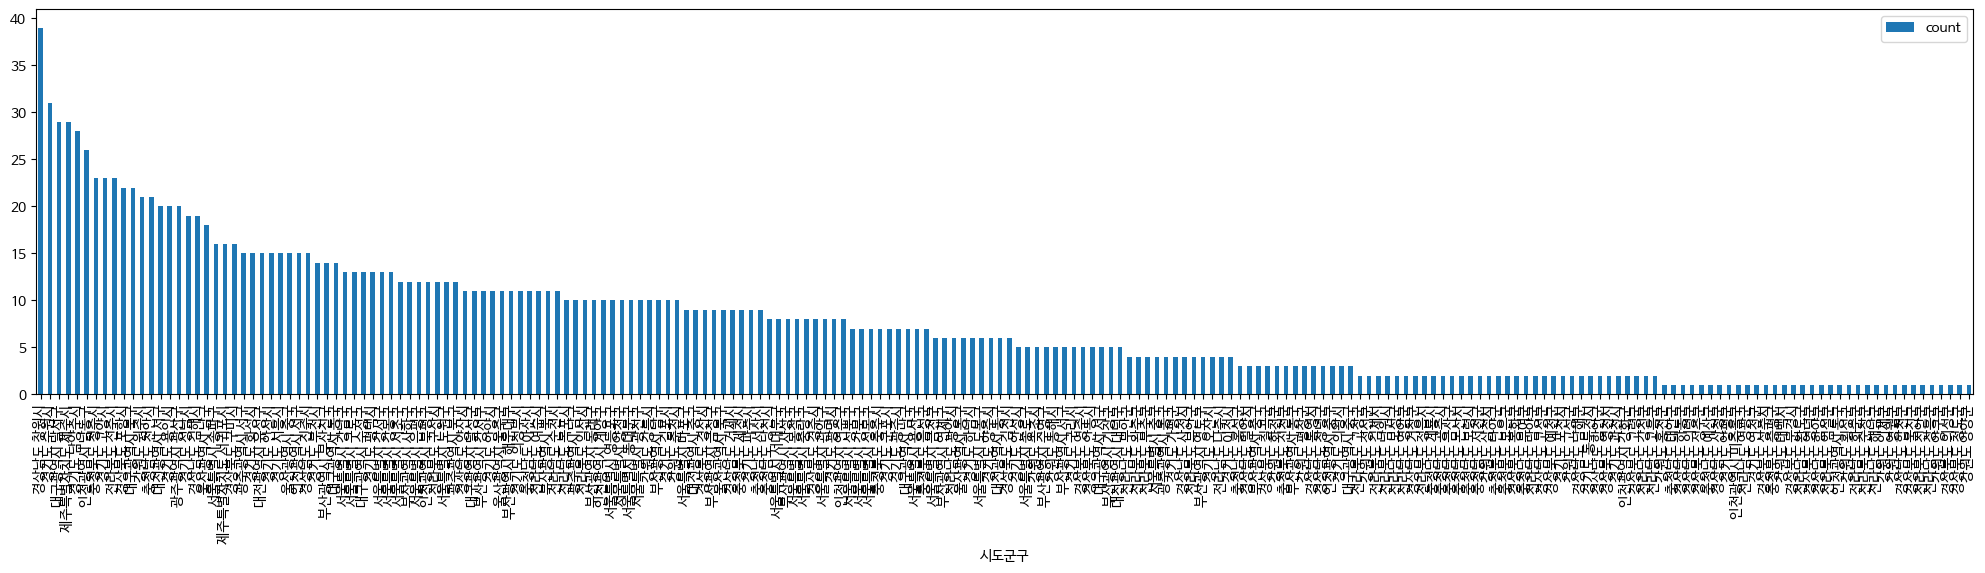

In [88]:
MC_ratio = local_MC_Population[['count']]
MC_ratio = MC_ratio.sort_values('count', ascending = False)
plt.rcParams["figure.figsize"] = (25, 5)
MC_ratio.plot(kind = 'bar', rot = 90)
plt.show()

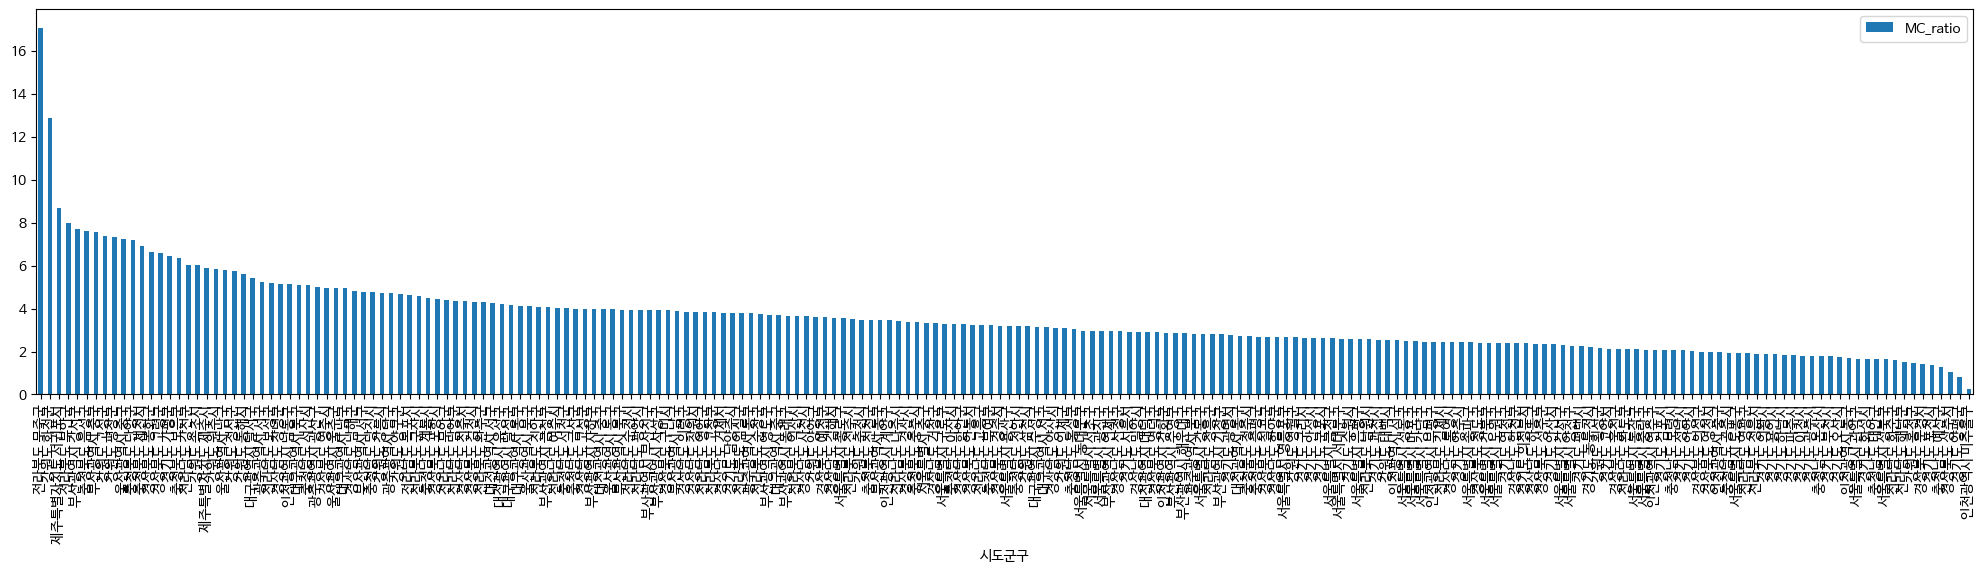

In [89]:
MC_ratio = local_MC_Population[['MC_ratio']]
MC_ratio = MC_ratio.sort_values('MC_ratio', ascending = False)
plt.rcParams["figure.figsize"] = (25, 5)
MC_ratio.plot(kind = 'bar', rot = 90)
plt.show()

In [90]:
BORDER_LINES = [
    [(3, 2), (5, 2), (5, 3), (9, 3), (9, 1)], # 인천
    [(2, 5), (3, 5), (3, 4), (8, 4), (8, 7), (7, 7), (7, 9), (4, 9), (4, 7), (1, 7)], # 서울
    [(1, 6), (1, 9), (3, 9), (3, 10), (8, 10), (8, 9),
     (9, 9), (9, 8), (10, 8), (10, 5), (9, 5), (9, 3)], # 경기도
    [(9, 12), (9, 10), (8, 10)], # 강원도
    [(10, 5), (11, 5), (11, 4), (12, 4), (12, 5), (13, 5),
     (13, 4), (14, 4), (14, 2)], # 충청남도
    [(11, 5), (12, 5), (12, 6), (15, 6), (15, 7), (13, 7),
     (13, 8), (11, 8), (11, 9), (10, 9), (10, 8)], # 충청북도
    [(14, 4), (15, 4), (15, 6)], # 대전시
    [(14, 7), (14, 9), (13, 9), (13, 11), (13, 13)], # 경상북도
    [(14, 8), (16, 8), (16, 10), (15, 10),
     (15, 11), (14, 11), (14, 12), (13, 12)], # 대구시
    [(15, 11), (16, 11), (16, 13)], # 울산시
    [(17, 1), (17, 3), (18, 3), (18, 6), (15, 6)], # 전라북도
    [(19, 2), (19, 4), (21, 4), (21, 3), (22, 3), (22, 2), (19, 2)], # 광주시
    [(18, 5), (20, 5), (20, 6)], # 전라남도
    [(16, 9), (18, 9), (18, 8), (19, 8), (19, 9), (20, 9), (20, 10)], # 부산시
]

In [91]:
def draw_blockMap(blockedMap, targetData, title, color ):
    whitelabelmin = (max(blockedMap[targetData]) - min(blockedMap[targetData])) * 0.25 + min(blockedMap[targetData])

    datalabel = targetData

    vmin = min(blockedMap[targetData])
    vmax = max(blockedMap[targetData])

    mapdata = blockedMap.pivot(index='y', columns='x', values=targetData)
    masked_mapdata = np.ma.masked_where(np.isnan(mapdata), mapdata)
    
    plt.figure(figsize=(8, 13))
    plt.title(title)
    plt.pcolor(masked_mapdata, vmin=vmin, vmax=vmax, cmap=color, edgecolor='#aaaaaa', linewidth=0.5)

    # 지역 이름 표시
    for idx, row in blockedMap.iterrows():
        annocolor = 'white' if row[targetData] > whitelabelmin else 'black'
    
        # 광역시는 구 이름이 겹치는 경우가 많아서 시단위 이름도 같이 표시한다. (중구, 서구)
        if row['광역시도'].endswith('시') and not row['광역시도'].startswith('세종'):
            dispname = '{}\n{}'.format(row['광역시도'][:2], row['행정구역'][:-1])
            if len(row['행정구역']) <= 2:
                dispname += row['행정구역'][-1]
        else:
            dispname = row['행정구역'][:-1]

        # 서대문구, 서귀포시 같이 이름이 3자 이상인 경우에 작은 글자로 표시한다.
        if len(dispname.splitlines()[-1]) >= 3:
            fontsize, linespacing = 9.5, 1.5
        else:
            fontsize, linespacing = 11, 1.2

        plt.annotate(dispname, (row['x']+0.5, row['y']+0.5), weight='bold',
                     fontsize=fontsize, ha='center', va='center', color=annocolor,
                     linespacing=linespacing)
    
    # 시도 경계 그린다.
    for path in BORDER_LINES:
        ys, xs = zip(*path)
        plt.plot(xs, ys, c='black', lw=4)

    plt.gca().invert_yaxis()
    #plt.gca().set_aspect(1)
    plt.axis('off')
    
    cb = plt.colorbar(shrink=.1, aspect=10)
    cb.set_label(datalabel)

    plt.tight_layout()
    
    plt.savefig('./9장_data_' + 'blockMap_' + targetData + '.png')
                      
    
    plt.show()   

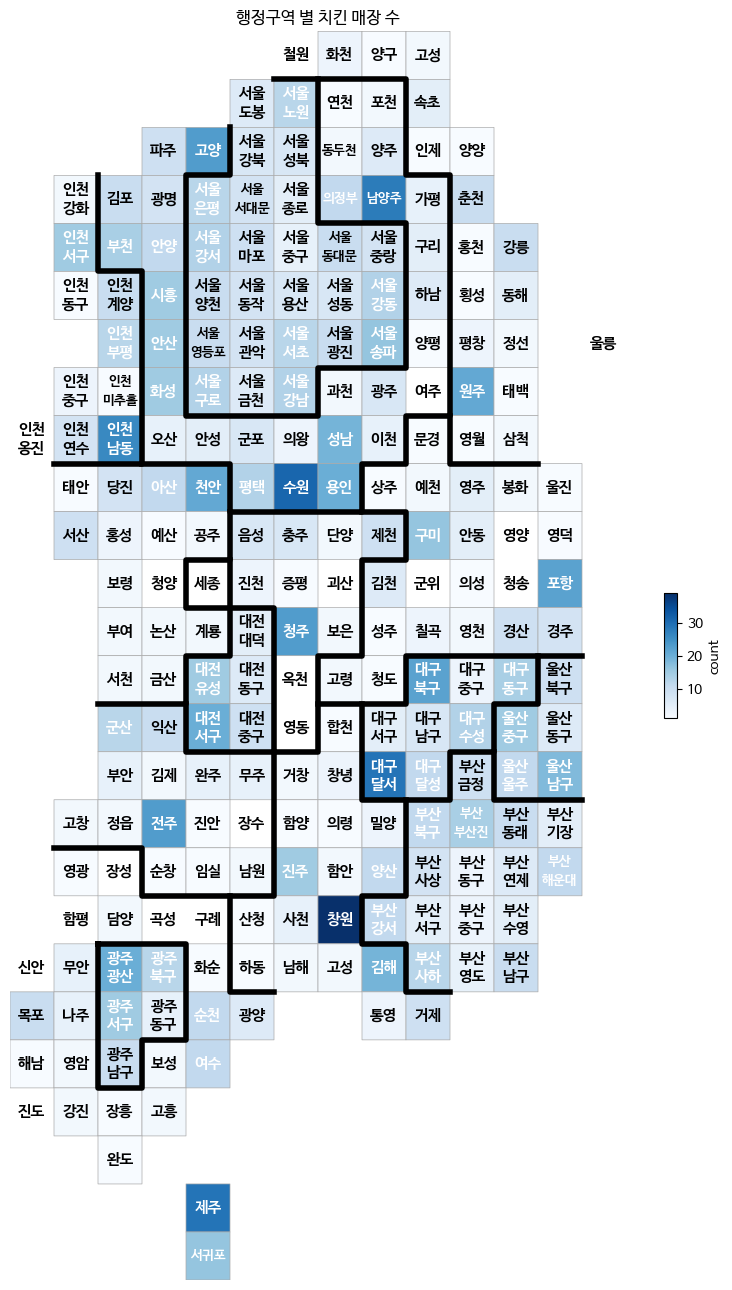

In [92]:
draw_blockMap(data_draw_korea_MC_Population_all, 'count', '행정구역 별 치킨 매장 수', 'Blues')

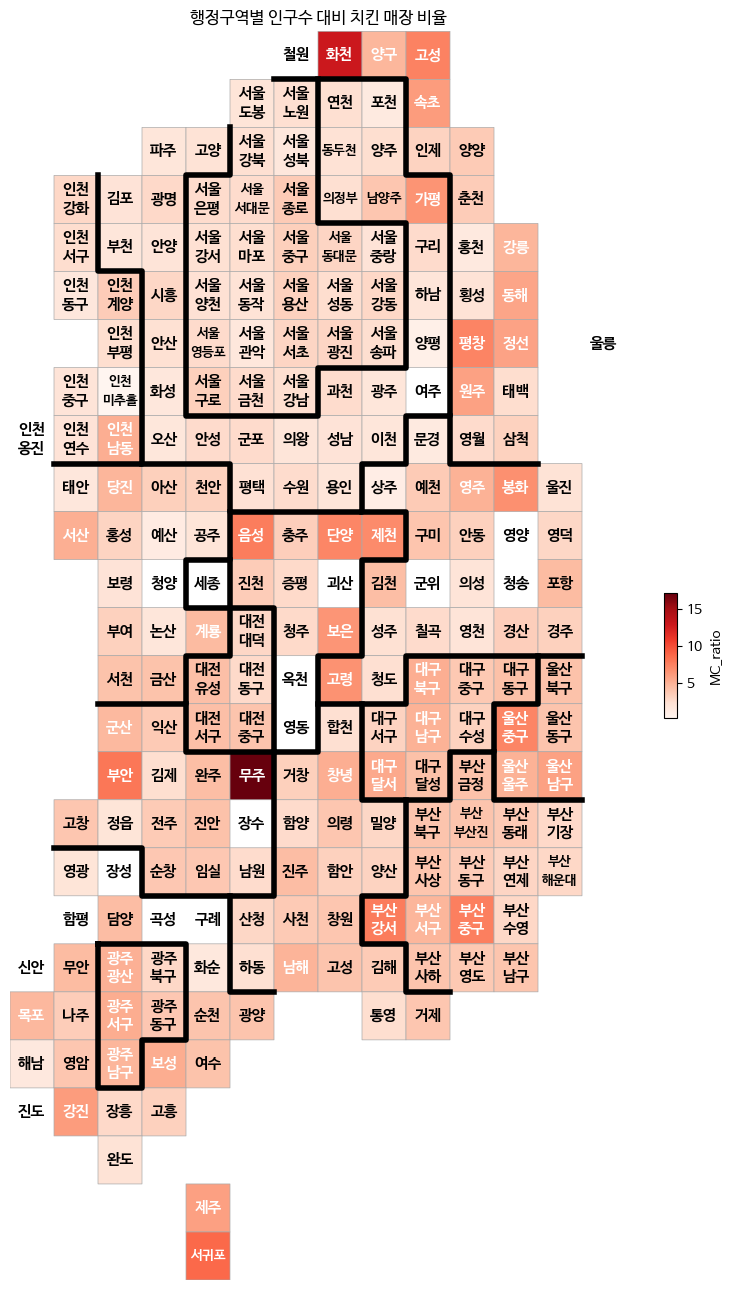

In [93]:
draw_blockMap(data_draw_korea_MC_Population_all, 'MC_ratio', '행정구역별 인구수 대비 치킨 매장 비율', 'Reds')